# 다이캐스팅 공정 데이터 기반 품질 예측 분석

## 프로젝트 개요
다이캐스팅은 융융 금속을 금형에 고압으로 주입하여 정밀한 제품을 생산하는 공정입니다.
생산 효율을 높이고 불량률을 낮추기 위해 공정변수(주조 온도, 압력, 속도 등) 및 센서 데이터를 분석하여 불량 유형을 자동 예측하는 머신러닝 모델을 개발합니다.

## 비즈니스 문제 정의
### 현재 상황
- 불량(미성형, 박리, 기공, 평탄, 개재물 등)이 발생해도 **육안 검사에 의존**하여 판정 기준의 주관성과 검사 속도의 한계로 인해 생산성이 저하됩니다.
- 불량 발생 원인을 추적하기 어려워 **공정 개선 및 문제 해결이 어렵습니다.**
- 공정 데이터와 품질 검사를 효과적으로 매핑하지 못해 **실시간 품질 관리 및 재발 방지 대책이 부족**합니다.

### 해결 필요성
- 공정변수 및 센서 데이터와 불량 유형 발생 간의 관계 파악 필요
- 불량 유형을 자동 분류하는 모델 개발로 품질 예측이 가능한 시스템 구축 필요
- 불량 발생 주요 원인을 분석하여 공정 최적화를 위한 인사이트 도출

## 분석 목표 및 KPI 설정
### 분석 목표
1. 다이캐스팅 공정에서 발생하는 다양한 불량 유형(미성형, 박리, 기공, 평탄, 개재물 등)을 자동 예측하는 머신러닝 모델을 개발
2. 공정 데이터(주조 압력, 금형 온도, 주입 속도 등)와 센서 데이터(온도, 압력, 유량, 진동 등)를 활용하여 불량 여부를 판별
4. 실시간 품질 예측 체계를 구축하여 조기 경보 시스템 도입 및 불량률 감소

### 비즈니스 KPI
- 현재 불량률 대비 불량률 10% 감소
- 불량 예측 모델의 정확도 90% 이상






In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [81]:
df = pd.read_csv('../../data/DieCasting_Quality_Raw_Data.csv', header=[0, 1])

print("="*60)
print("데이터셋 로드 완료!")
print("="*60)

print(df.shape)
df.info()

데이터셋 로드 완료!
(7535, 57)
<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness )   7535 non-null   int64  
 10  (Process, Clamping_Force )      7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float64
 12  (Process,  Pressure_Ri

In [82]:
# 데이터셋 샘플 확인
print("\n" + "="*60)
print("DieCasting 샘플 데이터")
print("="*60)
display(df.head())


DieCasting 샘플 데이터


Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                                        \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    
0               214           0.008                 10             258   
1               217           0.008                 11             257   
2               214           0.008                 11             257   
3               217           0.008                 11             257   
4               217           0.008                 12             257   

                                                                           \
  Cycle_Time  Pressure_Rise_Time Casting_Pressure Spray_Time Spray_1_Time   
0       20.7               0.044             1037        7.8          0.7   
1       20.7               0.044             1052        7.8          0.7   
2       20.8               0.041             1037        7.8          0.7   
3       20.7               0.043             1051        7.8          0.7   
4       20.7               0.042             1052        7.8          0.7   

                             Sensor                                \
  Spray_2_Time Melting_Furnace_Temp Air_Pressure Air_Pressure_Min   
0          0.8                695.0          6.3                3   
1          0.8                696.4          6.3                3   
2          0.8                696.4          6.3                3   
3          0.8                696.4          6.3                3   
4          0.8                697.9          6.4                3   

                                                                   \
  Air_Pressure_Max Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max   
0                9         26.0               10               50   
1                9         26.1               10               50   
2                9         26.1               10               50   
3                9         26.1               10               50   
4                9         26.1               10               50   

                                                                   \
  Coolant_Pressure Factory_Temp Factory_Temp_Min Factory_Temp_Max   
0             2.71         32.9             18.0             22.0   
1             2.69         32.9             18.0             22.0   
2             2.69         32.9             18.0             22.0   
3             2.69         32.9             18.0             22.0   
4             2.69         32.9             18.0             22.0   

                                                                  Defects  \
  Factory_Humidity Factory_Humidity_Min Factory_Humidity_Max Short_Shot_1   
0             58.4                 18.0                 22.0            0   
1             58.2                 18.0                 22.0            0   
2             58.2                 18.0                 22.0            0   
3             58.2                 18.0                 22.0            0   
4             57.8                 18.0                 22.0            0   

                                                                   \
  Bubble_1 Exfoliation_1 Blow_Hole_1 Stain_1 Dent_1 Deformation_1   
0        0             0           0       0      0             0   
1        0             0           0       0      0             0   
2        0             0           0       0      0             0   
3        0             1           0       0      0        

In [83]:
# 원본 데이터 기초 통계 확인
print("\n" + "="*60)
print("다이캐스팅 데이터셋 기초 통계")
print("="*60)
display(df.describe(include='all').T)


다이캐스팅 데이터셋 기초 통계


count          mean           std      min  \
Process id                    7535.0  3.767454e+06  2.175264e+06    1.000   
        Product_Type          7535.0  1.441672e+00  4.966192e-01    1.000   
        Shot                  7535.0  4.537989e+02  3.194517e+02    0.000   
        Velocity_1            7535.0  1.482190e-01  7.134201e-03    0.134   
        Velocity_2            7535.0  1.688005e-01  4.720277e-03    0.158   
        Velocity_3            7535.0  1.911928e-01  1.156281e-02    0.172   
        High_Velocity         7535.0  2.319210e+00  2.220408e-01    0.000   
        Cylinder_Pressure     7535.0  2.396556e+02  2.330545e+01  107.000   
        Rapid_Rise_Time       7535.0  9.596284e-03  2.147899e-03    0.000   
        Biscuit_Thickness     7535.0  1.430962e+01  3.286284e+00    0.000   
        Clamping_Force        7535.0  3.064333e+02  5.727496e+01  238.000   
        Cycle_Time            7535.0  2.773598e+01  8.716156e+00   20.200   
         Pressure_Rise_Time   7535.0  3.934811e-02  3.945136e-03    0.000   
        Casting_Pressure      7535.0  8.569441e+02  2.348155e+02  516.000   
        Spray_Time            7535.0  9.815979e+00  1.842438e+00    7.000   
        Spray_1_Time          7535.0  1.409104e+00  5.570595e-01    0.700   
        Spray_2_Time          7535.0  1.396045e+00  7.161698e-01    0.700   
Sensor  Melting_Furnace_Temp  7535.0  6.806527e+02  2.528867e+01  635.300   
        Air_Pressure          7535.0  6.109595e+00  6.479057e-01    4.600   
        Air_Pressure_Min      7535.0  3.000000e+00  0.000000e+00    3.000   
        Air_Pressure_Max      7535.0  9.000000e+00  0.000000e+00    9.000   
        Coolant_Temp          7535.0  2.683013e+01  5.251495e-01   25.900   
        Coolant_Temp_Min      7535.0  1.000000e+01  0.000000e+00   10.000   
        Coolant_Temp_Max      7535.0  5.000000e+01  0.000000e+00   50.000   
        Coolant_Pressure      7535.0  2.701155e+00  5.240785e-02    2.580   
        Factory_Temp          7445.0  3.282968e+01  1.674896e+00   27.400   
        Factory_Temp_Min      7445.0  1.800000e+01  0.000000e+00   18.000   
        Factory_Temp_Max      7445.0  2.200000e+01  0.000000e+00   22.000   
        Factory_Humidity      7445.0  6.167300e+01  7.031202e+00   45.500   
        Factory_Humidity_Min  7445.0  1.800000e+01  0.000000e+00   18.000   
        Factory_Humidity_Max  7445.0  2.200000e+01  0.000000e+00   22.000   
Defects Short_Shot_1          7535.0  6.794957e-02  2.594663e-01    0.000   
        Bubble_1              7535.0  9.555408e-03  9.729007e-02    0.000   
        Exfoliation_1         7535.0  2.322495e-02  1.523794e-01    0.000   
        Blow_Hole_1           7535.0  3.251493e-02  1.958671e-01    0.000   
        Stain_1               7535.0  2.773723e-02  1.796684e-01    0.000   
        Dent_1                7535.0  9.289980e-04  3.046733e-02    0.000   
        Deformation_1         7535.0  1.446583e-02  1.205152e-01    0.000   
        Contamination_1       7535.0  5.308560e-04  2.303572e-02    0.000   
        Impurity_1            7535.0  2.654280e-04  1.629088e-02    0.000   
        Crack_1               7535.0  1.327140e-04  1.152016e-02    0.000   
        Scratch_1             7535.0  2.654280e-04  1.629088e-02    0.000   
        Buring_Mark_1         7535.0  6.635700e-04  2.575301e-02    0.000   
        Inclusions_1          7535.0  0.000000e+00  0.000000e+00    0.000   
        Short_Shot_2          7535.0  2.415395e-02  1.552565e-01    0.000   
        Bubble_2              7535.0  1.194426e-03  4.152209e-02    0.000   
        Exfoliation_2         7535.0  1.778368e-02  1.351522e-01    0.000   
        Blow_Hole_2           7535.0  2.136695e-02  1.500199e-01    0.000   
        Stain_2               7535.0  0.000000e+00  0.000000e+00    0.000   
        Dent_2                7535.0  5.308560e-04  2.303572e-02    0.000   
        Deformation_2         7535.0  8.626410e-03  9.390737e-02    0.000   
        Contamination_2    

## 2. 데이터 전처리

### 2-1. 컬럼명 공백 제거

In [84]:
df.rename(columns={'Biscuit_Thickness ': 'Biscuit_Thickness', 'Clamping_Force ': 'Clamping_Force', ' Pressure_Rise_Time': 'Pressure_Rise_Time'}, level=1, inplace=True)

### 2-2. 컬럼명 소문자 전환

In [85]:
df.columns = df.columns.map(lambda x: tuple(str(level).lower() for level in x))

### 2-3. 불필요한 컬럼 제거
id 값은 데이터와 무관하다고 판단하기 때문에 제거

In [86]:
df.drop(columns=[('process', 'id')], inplace=True)
print("="*60)
print("id 컬럼 제거 완료!")
print("="*60)

id 컬럼 제거 완료!


### 2-3. 중복 데이터 확인

id 값을 제외하고 모든 컬럼의 값이 동일한 중복 행 제거

In [87]:
### 2. 중복 제거
# 모든 남아있는 컬럼을 기준으로 중복 제거
initial_row_count = len(df)
df = df.drop_duplicates(keep='first').reset_index(drop=True)
final_row_count = len(df)

# 결과 확인
print(f"제거 전 행 개수: {initial_row_count}")
print(f"제거 후 행 개수: {final_row_count}")
print(f"삭제된 중복 행 개수: {initial_row_count - final_row_count}")

제거 전 행 개수: 7535
제거 후 행 개수: 4617
삭제된 중복 행 개수: 2918


### 2-4. 결측치 확인
몇 개의 컬럼에서 결측치가 확인되지만 학습/정답 데이터 분리를 위해 우선은 그대로 유지

In [88]:
missing_process_sensor = df.loc[:, (['process', 'sensor'], slice(None))].isna().sum()
missing_process_sensor = missing_process_sensor[missing_process_sensor > 0].reset_index()
missing_process_sensor.columns = ['', 'Columns', 'Missing Count']
display(missing_process_sensor)

,,Columns,Missing Count
0,sensor,factory_temp,45
1,sensor,factory_temp_min,45
2,sensor,factory_temp_max,45
3,sensor,factory_humidity,45
4,sensor,factory_humidity_min,45
5,sensor,factory_humidity_max,45


### 2-5. 파생 컬럼 생성
불량 유무를 파악하기 위한 파생 컬럼 생성

In [89]:
### 4. 새로운 파생컬럼 생성

# MultiIndex 컬럼으로 'defect_flag'가 존재하는지 확인
if ('defect_flag', 'is_defect') not in df.columns:
    defect_cols = [col for col in df.columns if col[0]=='defects']
    df[('defect_flag','is_defect')] = (df[defect_cols] == 1).any(axis=1).astype(int)
    print("="*60)
    print("파생 컬럼 생성 완료!")
    print("불량 유무 (0: 정상, 1: 불량) 분포:")
    print(df[('defect_flag','is_defect')].value_counts()) # --> 0: 정상, 1: 불량
    print("="*60)
else:
    print("="*60)
    print("파생 컬럼이 이미 존재합니다!")
    print("="*60)

print(f"DataFrame shape: {df.shape}")
display(df.head(5))

파생 컬럼 생성 완료!
불량 유무 (0: 정상, 1: 불량) 분포:
(defect_flag, is_defect)
0    3576
1    1041
Name: count, dtype: int64
DataFrame shape: (4617, 57)


process                                                      \
  product_type shot velocity_1 velocity_2 velocity_3 high_velocity   
0            1    1      0.144      0.170      0.188         2.134   
1            1    2      0.144      0.170      0.182         2.124   
2            1    3      0.144      0.170      0.182         2.116   
3            1    4      0.144      0.170      0.182         2.137   
4            1    5      0.144      0.172      0.176         2.111   

                                                                      \
  cylinder_pressure rapid_rise_time biscuit_thickness clamping_force   
0               214           0.008                10            258   
1               217           0.008                11            257   
2               214           0.008                11            257   
3               217           0.008                11            257   
4               217           0.008                12            257   

                                                                          \
  cycle_time pressure_rise_time casting_pressure spray_time spray_1_time   
0       20.7              0.044             1037        7.8          0.7   
1       20.7              0.044             1052        7.8          0.7   
2       20.8              0.041             1037        7.8          0.7   
3       20.7              0.043             1051        7.8          0.7   
4       20.7              0.042             1052        7.8          0.7   

                             sensor                                \
  spray_2_time melting_furnace_temp air_pressure air_pressure_min   
0          0.8                695.0          6.3                3   
1          0.8                696.4          6.3                3   
2          0.8                696.4          6.3                3   
3          0.8                696.4          6.3                3   
4          0.8                697.9          6.4                3   

                                                                   \
  air_pressure_max coolant_temp coolant_temp_min coolant_temp_max   
0                9         26.0               10               50   
1                9         26.1               10               50   
2                9         26.1               10               50   
3                9         26.1               10               50   
4                9         26.1               10               50   

                                                                   \
  coolant_pressure factory_temp factory_temp_min factory_temp_max   
0             2.71         32.9             18.0             22.0   
1             2.69         32.9             18.0             22.0   
2             2.69         32.9             18.0             22.0   
3             2.69         32.9             18.0             22.0   
4             2.69         32.9             18.0             22.0   

                                                                  defects  \
  factory_humidity factory_humidity_min factory_humidity_max short_shot_1   
0             58.4                 18.0                 22.0            0   
1             58.2                 18.0                 22.0            0   
2             58.2                 18.0                 22.0            0   
3             58.2                 18.0                 22.0            0   
4             57.8                 18.0                 22.0            0   

                                                                   \
  bubble_1 exfoliation_1 blow_hole_1 stain_1 dent_1 deformation_1   
0        0             0           0       0      0             0   
1        0             0           0       0      0             0   
2        0             0           0       0      0             0   
3        0             1           0       0      0             0   
4        0             0           0       0      0             0   

  

## 3. 데이터 시각화

### 3-1. 데이터의 히스토그램 확인
- 히스토그램에서 몇몇 데이터의 이봉분포 확인됨
- 상품 유형에 따른 데이터 차이가 발생하기 때문으로 확인
- 상품 유형 별로 데이터를 분리한 분석 진행이 필요하다고 판단

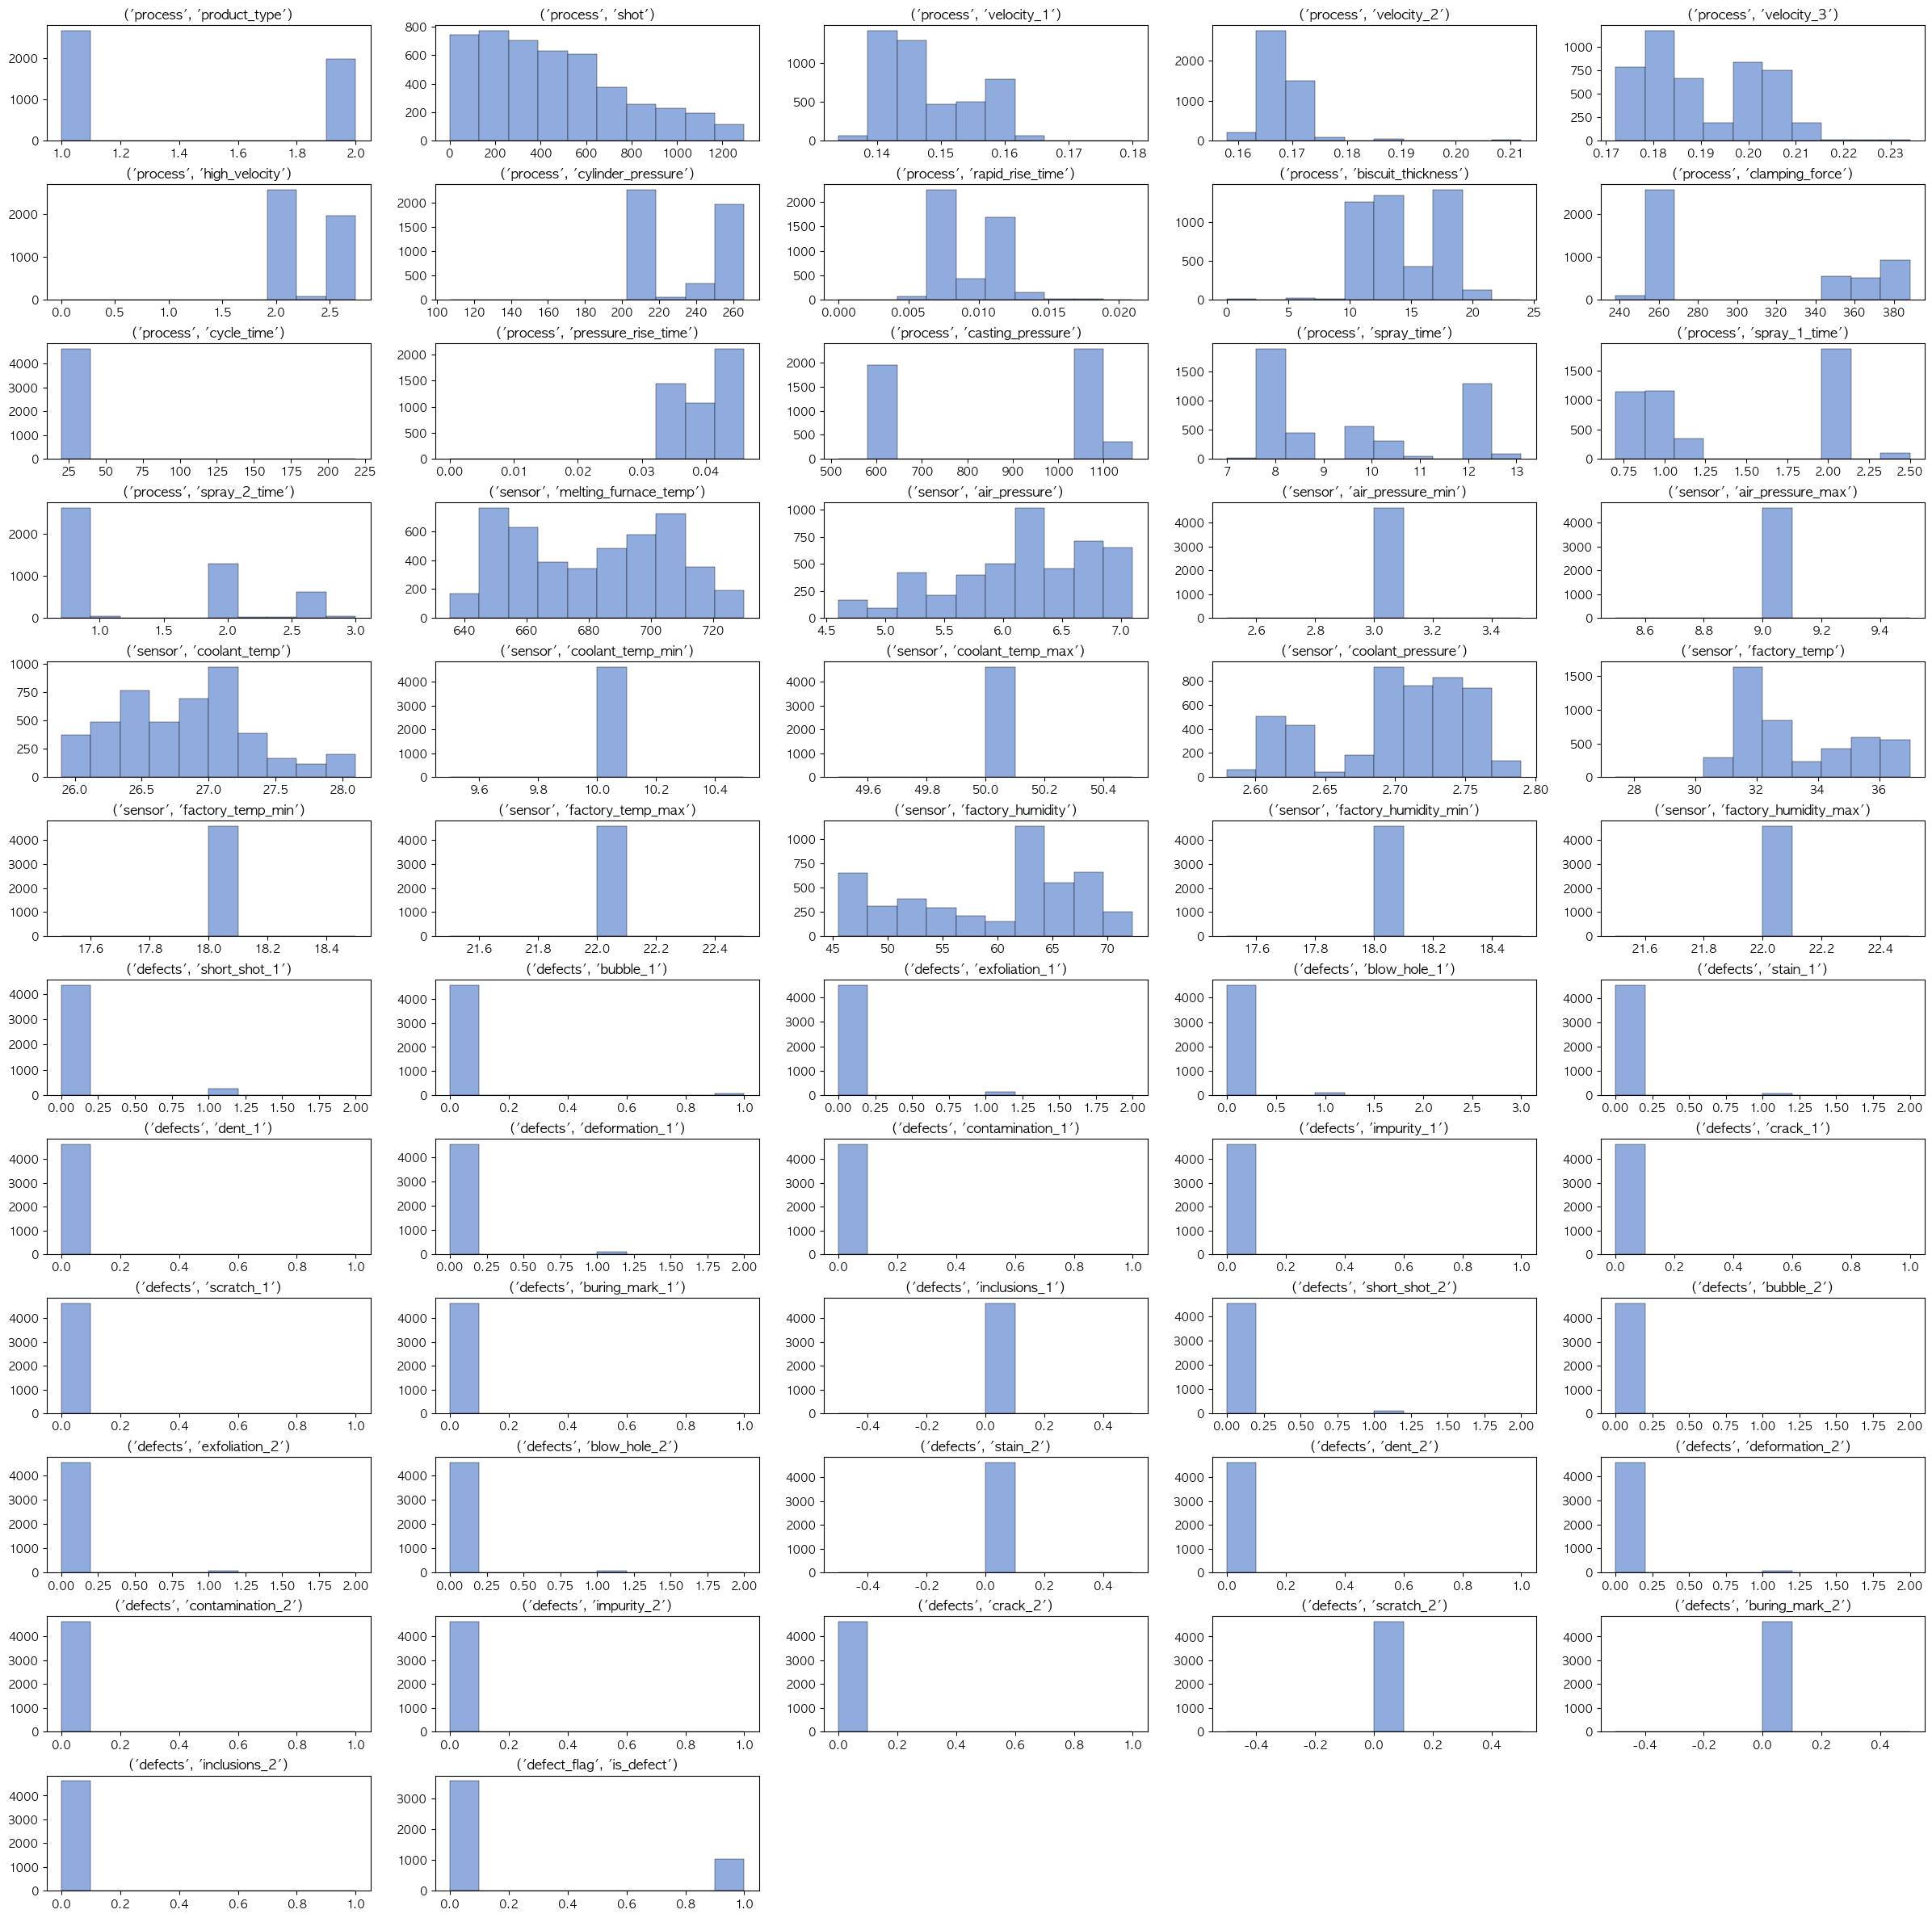

In [90]:
plt.figure(figsize=(30,30))
plt.subplots_adjust(hspace=0.38)
# 각 변수의 막대그래프 개수
for index,value in enumerate(df):
 sub=plt.subplot(12,5,index+1)
 sub.hist(df[value],facecolor=(144/255,171/255,221/255),
	 	 	 linewidth=.3,edgecolor='black')
 plt.title(value)

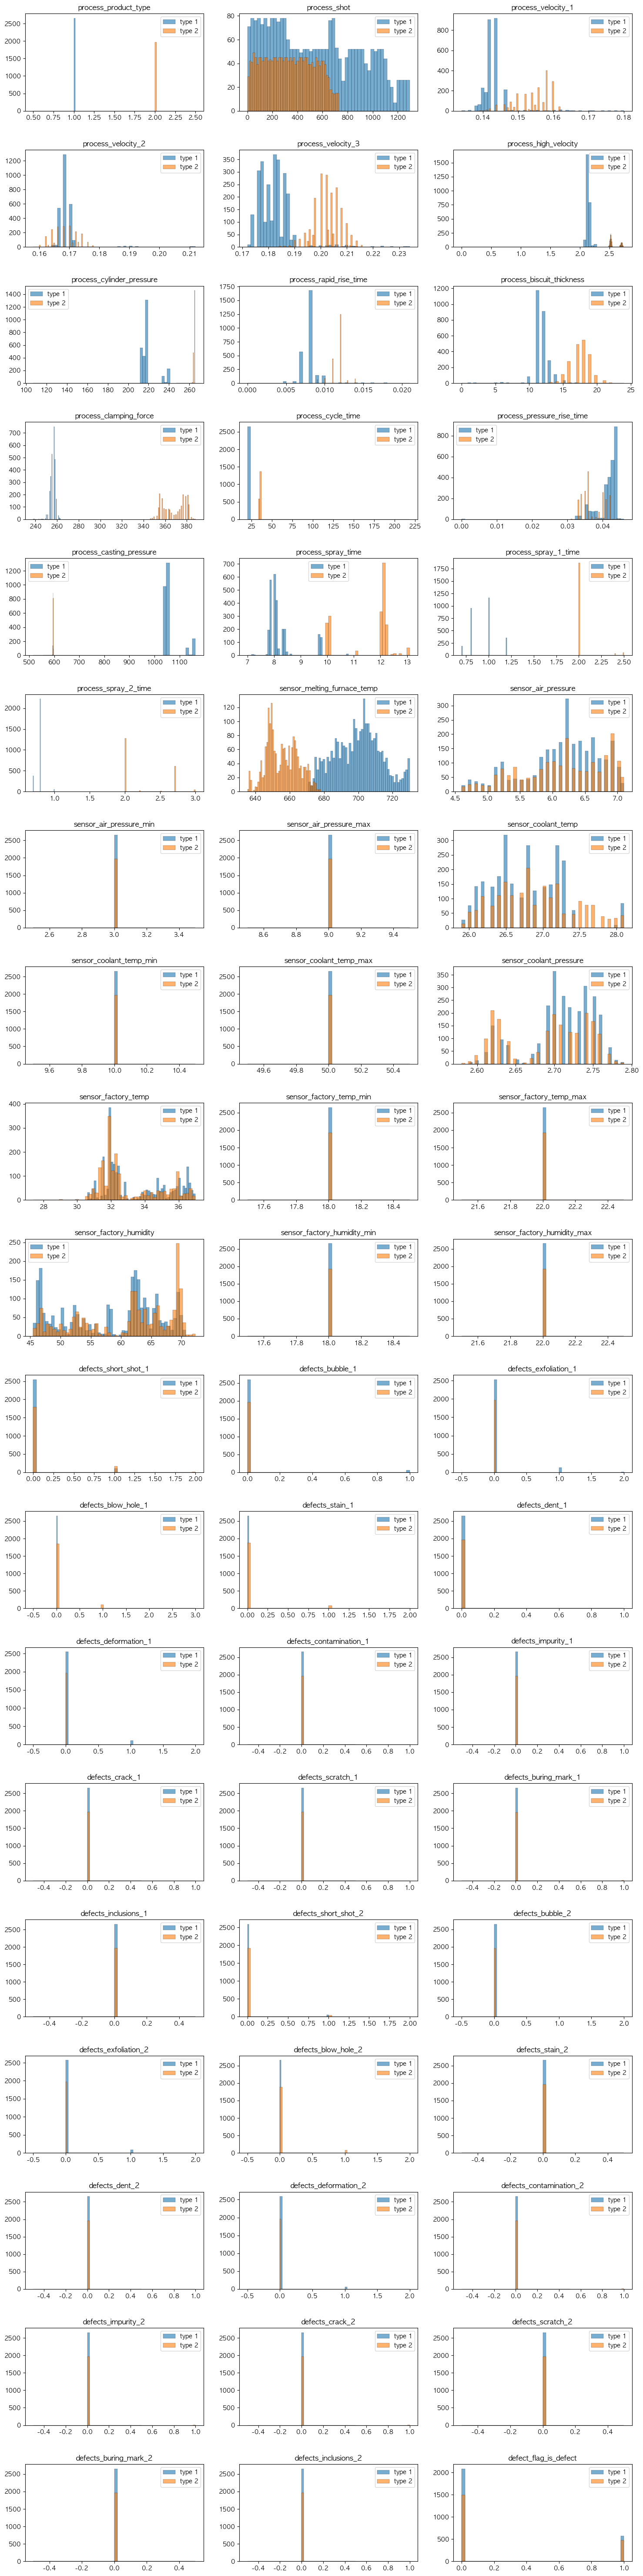

In [91]:
# product_type 별 히스토그램 시각화
product_type_1 = df[df[('process', 'product_type')] == 1]
product_type_2 = df[df[('process', 'product_type')] == 2]

num_cols = [col for col in df.columns if df[col].dtype in ['float64', 'int64']]
num_total = len(num_cols)

n_cols_per_row = 3
n_rows = (num_total + n_cols_per_row - 1) // n_cols_per_row

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols_per_row, figsize=(n_cols_per_row * 6, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(product_type_1[col].dropna(), bins=50, alpha=0.6, edgecolor='black', linewidth=0.3, label='type 1')
    axes[i].hist(product_type_2[col].dropna(), bins=50, alpha=0.6, edgecolor='black', linewidth=0.3, label='type 2')
    axes[i].set_title(f'{col[0]}_{col[1]}')
    axes[i].legend()

for j in range(num_total, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.4)
plt.show()

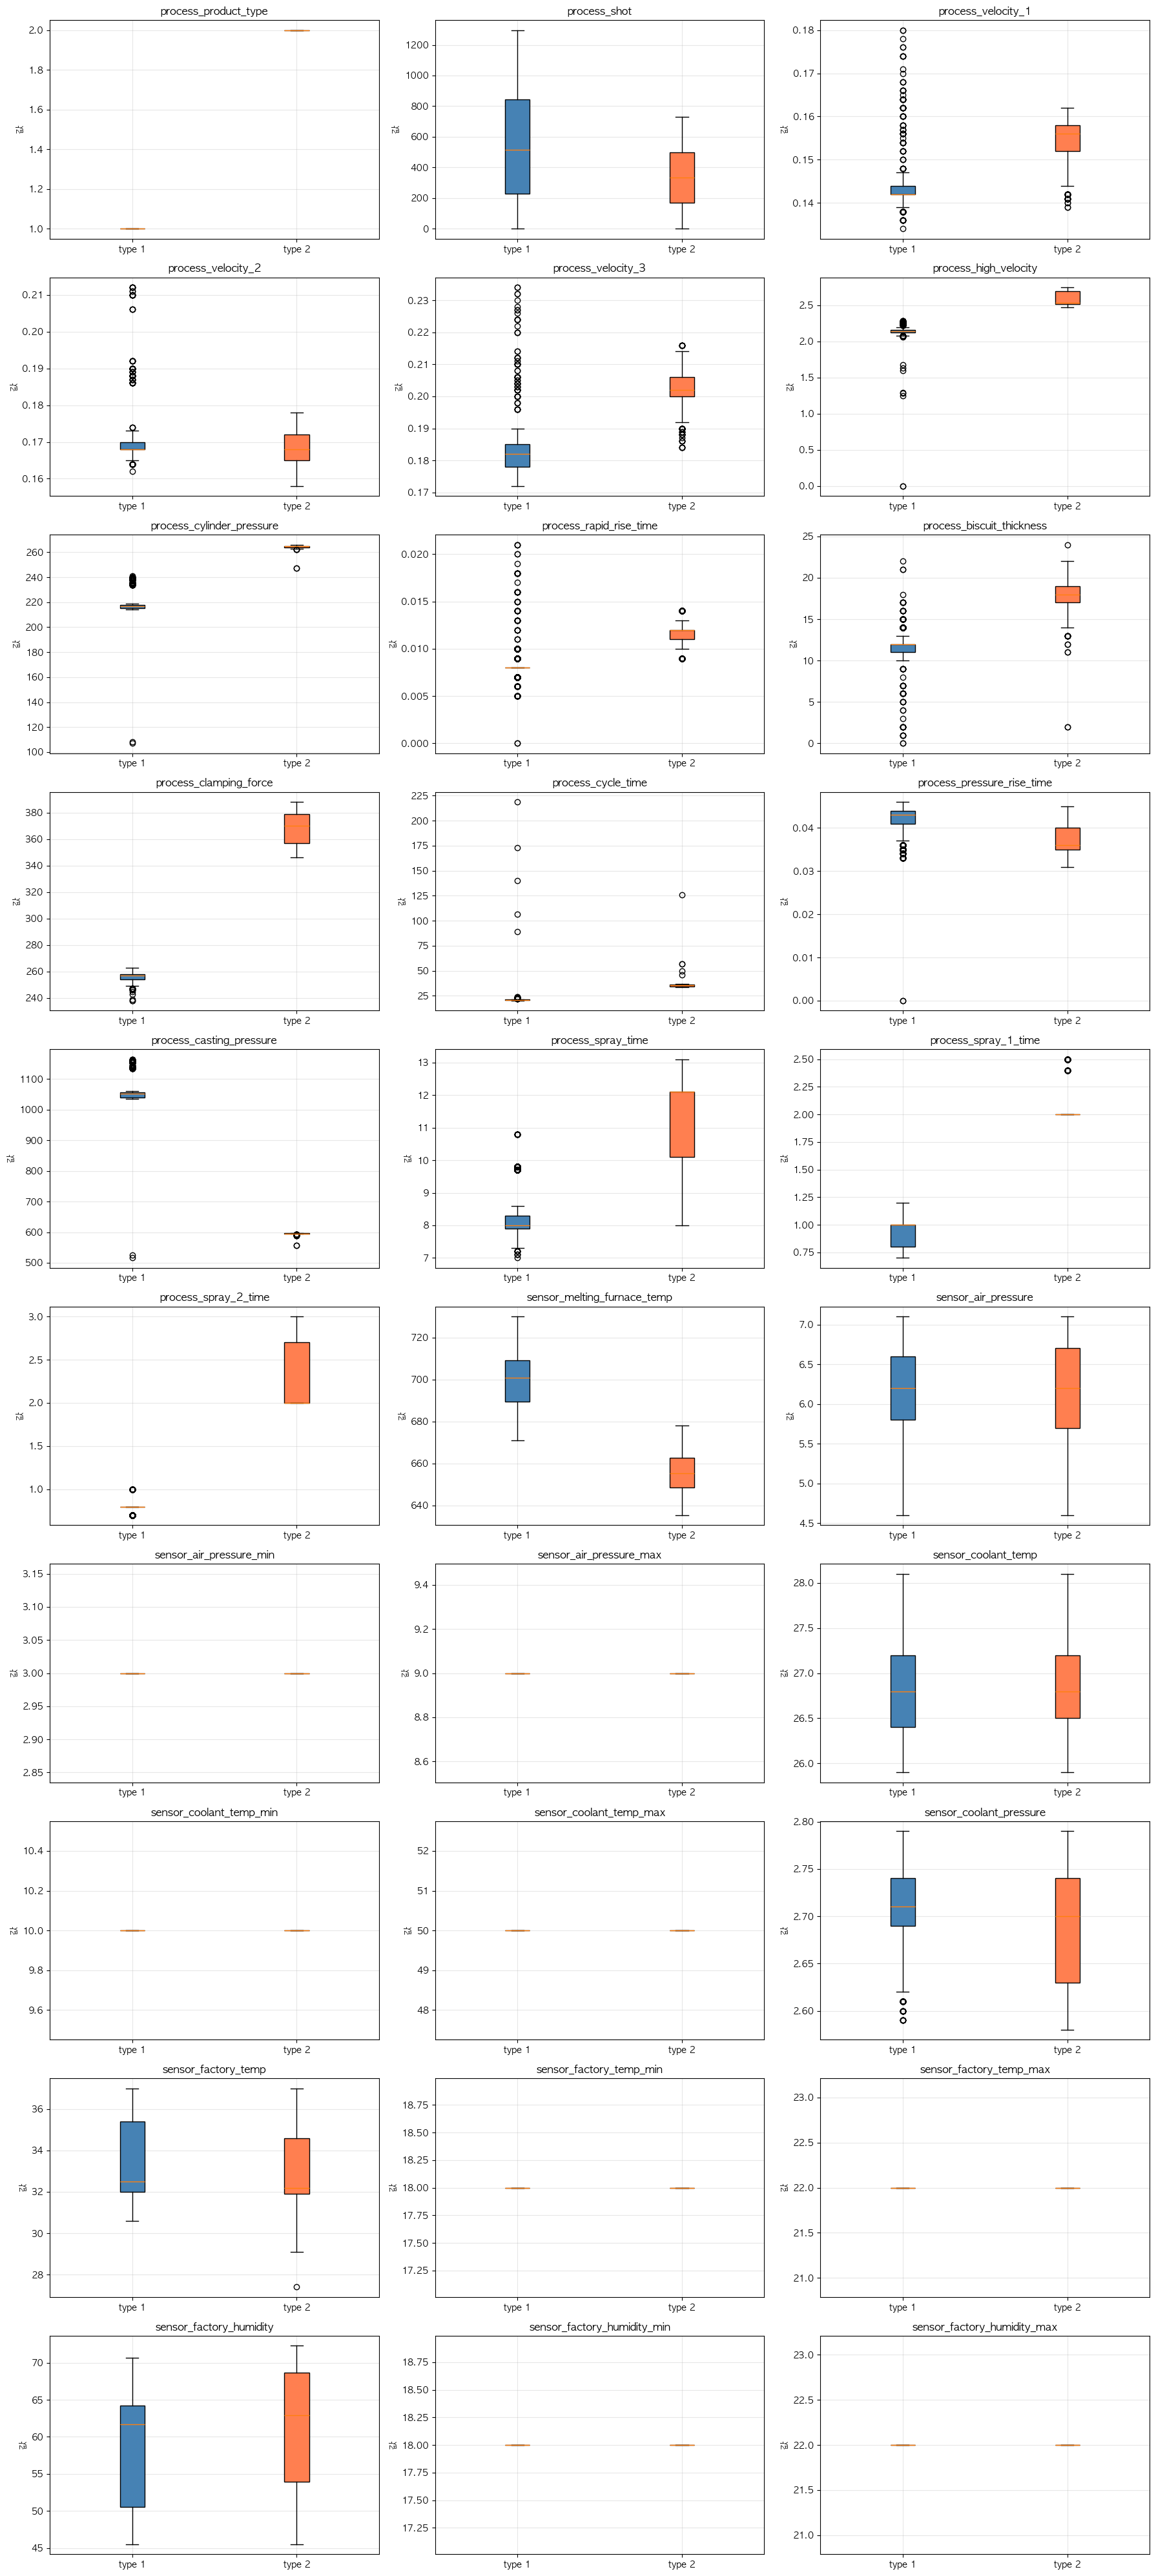

In [92]:
# process, sensor 컬럼 박스플롯 (product_type 1, 2 비교)
product_type_1 = df[df[('process', 'product_type')] == 1]
product_type_2 = df[df[('process', 'product_type')] == 2]

ps_cols = [(lvl0, lvl1) for lvl0, lvl1 in df.columns if lvl0 in ['process', 'sensor']]
num_total = len(ps_cols)

n_cols_per_row = 3
n_rows = (num_total + n_cols_per_row - 1) // n_cols_per_row

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols_per_row, figsize=(n_cols_per_row * 6, n_rows * 4))
axes = axes.flatten()

for i, (lvl0, lvl1) in enumerate(ps_cols):
    data = [product_type_1[(lvl0, lvl1)].dropna(), product_type_2[(lvl0, lvl1)].dropna()]
    bp = axes[i].boxplot(data, labels=['type 1', 'type 2'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    axes[i].set_title(f'{lvl0}_{lvl1}')
    axes[i].set_ylabel('값')
    axes[i].grid(True, alpha=0.3)

for j in range(num_total, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 3. 이상치 확인 및 처리


### 3-1. 불량 유형 여부 이상치
불량 유형에 해당되는 1(불량), 0(정상) 값을 벗어나는 2 또는 3과 같은 값을 1(불량) 값으로 대체




In [93]:
### 3. 2,3을 불량 1로 대체
defect_cols = df['defects'].columns

# 'Defects' 대분류 아래의 모든 컬럼에 대해 2 이상의 값을 1로 변경
for col in defect_cols:
    # Defects 하위의 col 값 중 2 이상인 경우를 1로 치환
    df.loc[df[('defects', col)] >= 2, ('defects', col)] = 1

print("="*60)
print("이상치 값 대체 완료!")
print("="*60)

이상치 값 대체 완료!


In [94]:
print("="*60)
print("불량유형 컬럼 중 1(불량)값이 전혀 없는 컬럼 (_1/_2 개별 기준):")
print("="*60)

defect_cols = df['defects'].columns
zero_value_defect_cols = [col for col in defect_cols if df[('defects', col)].sum() == 0]

if zero_value_defect_cols:
    for col in zero_value_defect_cols:
        print(f"- {col}")
else:
    print("1값이 없는 불량유형 컬럼이 없습니다.")
print("="*60)

불량유형 컬럼 중 1(불량)값이 전혀 없는 컬럼 (_1/_2 개별 기준):
- inclusions_1
- stain_2
- scratch_2
- buring_mark_2


### 3-2. 불량유형 컬럼 통합
- 같은 불량유형이지만 cavity1, 2로 나뉜 `_1`, `_2`컬럼들을 cavity 번호를 제외하고 같은 컬럼명으로 통합.
- 통합 전 `_1` 이나 `_2` 중 둘 중 하나라도 불량 여부가 `1(불량)` 이라면 불량이라고 판단하여 값을 `1` 로 넣음

In [95]:
# 불량유형 중 cavity 1, 2 컬럼을 통합
print("="*60)
print("기존 불량유형 컬럼 및 불량 개수 확인:")
print("="*60)

defect_cols = df['defects'].columns

for col in defect_cols:
    print(f"{col}: {df['defects', col].sum()}")

defect_types = []
for col in defect_cols:
    new_col = col.replace("_1", "").replace("_2", "")
    if new_col not in defect_types:
        defect_types.append(new_col)

for col in defect_types:
    df[('defects', col)] = 0
    df.loc[(df[('defects', f'{col}_1')] == 1) | (df[('defects', f'{col}_2')] == 1), ('defects', col)] = 1

print("="*60)
# 1. 새로 만들어진 통합 컬럼 확인
print("새로 만들어진 통합 컬럼 확인:")
print("="*60)
print(f"{df['defects'][defect_types].sum()}")

# 2. 결측치 없는지 확인
print("="*60)
print("NaN 없는지 확인:")
print("="*60)
print(f"{df['defects'][defect_types].isna().sum()}")

print("="*60)
# 기존 _1, _2 컬럼 제거
cols_to_drop = [('defects', col) for col in defect_cols if col.endswith('_1') or col.endswith('_2')]
df.drop(columns=cols_to_drop, inplace=True)
print("기존 컬럼 제거 완료!")
print("="*60)

df.info()

기존 불량유형 컬럼 및 불량 개수 확인:
short_shot_1: 284
bubble_1: 61
exfoliation_1: 124
blow_hole_1: 112
stain_1: 96
dent_1: 7
deformation_1: 108
contamination_1: 4
impurity_1: 2
crack_1: 1
scratch_1: 2
buring_mark_1: 5
inclusions_1: 0
short_shot_2: 108
bubble_2: 5
exfoliation_2: 86
blow_hole_2: 79
stain_2: 0
dent_2: 4
deformation_2: 64
contamination_2: 8
impurity_2: 5
crack_2: 2
scratch_2: 0
buring_mark_2: 0
inclusions_2: 1
새로 만들어진 통합 컬럼 확인:
short_shot       387
bubble            66
exfoliation      203
blow_hole        184
stain             96
dent              11
deformation      169
contamination     11
impurity           7
crack              3
scratch            2
buring_mark        5
inclusions         1
dtype: int64
NaN 없는지 확인:
short_shot       0
bubble           0
exfoliation      0
blow_hole        0
stain            0
dent             0
deformation      0
contamination    0
impurity         0
crack            0
scratch          0
buring_mark      0
inclusions       0
dtype: int64
기존 컬럼 제거 완

In [96]:
print("="*60)
print("불량유형 컬럼 중 0밖에 없는 컬럼:")
print("="*60)

defect_cols = df['defects'].columns

# 통합된 불량 유형 컬럼들 중에서 값이 모두 0인 컬럼을 찾습니다.
zero_value_defect_cols = []
for col in defect_cols:
    if df[('defects', col)].sum() == 0:
        zero_value_defect_cols.append(col)

if zero_value_defect_cols:
    for col in zero_value_defect_cols:
        print(f"- {col}")
else:
    print("값이 0밖에 없는 불량유형 컬럼이 없습니다.")
print("="*60)

불량유형 컬럼 중 0밖에 없는 컬럼:
값이 0밖에 없는 불량유형 컬럼이 없습니다.


### 3-2. product_type 별 데이터 분리 및 데이터 csv 저장


In [98]:
# product_type 별 데이터 분리
product_type_1 = df[df[('process', 'product_type')] == 1]
product_type_2 = df[df[('process', 'product_type')] == 2]

print("="*60)
print("product_type 컬럼 제거 전:")
print("="*60)
print(f"type_1: {product_type_1.shape}")
print(f"type_2: {product_type_2.shape}")

# product_type 컬럼 제거
product_type_1 = product_type_1.drop(columns=[('process', 'product_type')])
product_type_2 = product_type_2.drop(columns=[('process', 'product_type')])

print("="*60)
print("product_type 컬럼 제거 후:")
print("="*60)
print(f"type1: {product_type_1.shape}")
print(f"type2: {product_type_2.shape}")

# 유형 별 파일 저장
product_type_1.to_csv('../../data_processed/product_type_1.csv', index=False, encoding='utf-8-sig')
product_type_2.to_csv('../../data_processed/product_type_2.csv', index=False, encoding='utf-8-sig')

print("="*60)
print("파일 저장 완료!:")
print("="*60)

product_type 컬럼 제거 전:
type_1: (2653, 44)
type_2: (1964, 44)
product_type 컬럼 제거 후:
type1: (2653, 43)
type2: (1964, 43)
파일 저장 완료!:
